<pre style="color:green;">
Assignment 1    :   Fundamentals of Probability
Course          :   ME2050
Reg. No.        :   E/22/445
Name            :   P.M.S.S. Wjethunga
</pre>

---

### Import necessary libraries

In [1]:
import numpy as np
from matplotlib import pyplot as plt

# Q1) The Probability of Shooting at a Target

A point is chosen at random from a disk of radius $10$. Let $A$ be the event that the point lies within $1$ unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.
2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.
3. Explain why the two answers differ.


### Answers for Q1

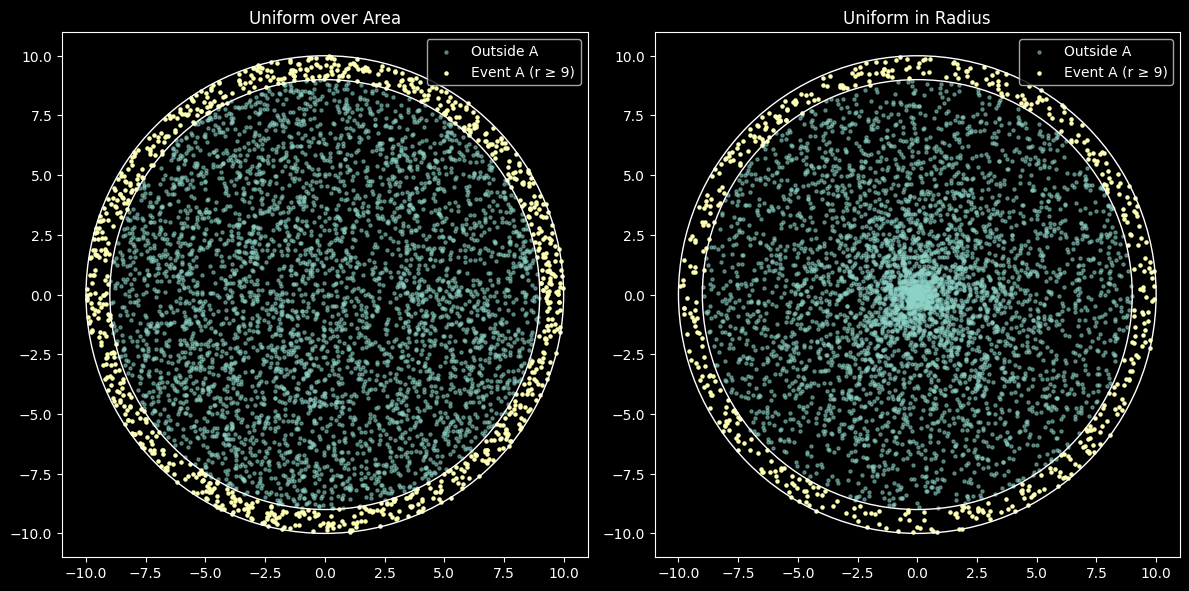

In [9]:
# Visualization of the Area and Radius Models for Q1

# Number of random points
N = 5000

# 1. Model the experiment assuming the point is uniformly distributed with respect to area
theta1 = np.random.uniform(0, 2*np.pi, N)
r1 = 10 * np.sqrt(np.random.uniform(0, 1, N))

x1 = r1 * np.cos(theta1)
y1 = r1 * np.sin(theta1)

# Points in event A (9 <= r <= 10)
mask1 = (r1 >= 9)

# 2. Model the experiment assuming the distance to the point from the center is chosen uniformly
theta2 = np.random.uniform(0, 2*np.pi, N)
r2 = np.random.uniform(0, 10, N)  # uniform radius

x2 = r2 * np.cos(theta2)
y2 = r2 * np.sin(theta2)

mask2 = (r2 >= 9)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1.
axes[0].scatter(x1[~mask1], y1[~mask1], s=5, alpha=0.5, label='Outside A')
axes[0].scatter(x1[mask1], y1[mask1], s=5, label='Event A (r ≥ 9)')

circle_outer = plt.Circle((0, 0), 10, fill=False)
circle_inner = plt.Circle((0, 0), 9, fill=False)

axes[0].add_patch(circle_outer)
axes[0].add_patch(circle_inner)

axes[0].set_title("Uniform over Area")
axes[0].set_aspect('equal')
axes[0].legend()

# Plot 2.
axes[1].scatter(x2[~mask2], y2[~mask2], s=5, alpha=0.5, label='Outside A')
axes[1].scatter(x2[mask2], y2[mask2], s=5, label='Event A (r ≥ 9)')

circle_outer2 = plt.Circle((0, 0), 10, fill=False)
circle_inner2 = plt.Circle((0, 0), 9, fill=False)

axes[1].add_patch(circle_outer2)
axes[1].add_patch(circle_inner2)

axes[1].set_title("Uniform in Radius")
axes[1].set_aspect('equal')
axes[1].legend()

plt.tight_layout()
plt.show()

##### $$\Omega=\{(r,\theta)\in \mathbb{R}^2 : r\le10 ; \theta\in[0,2\pi] ;\}$$
##### $$A=\{(r,\theta)\in \Omega : 9\le r \le 10; \theta\in[0,2\pi] ;\}$$

$$\textbf{Case 1: Uniform with respect to area}$$

$$P(A) = \frac{\pi (10)^2 - \pi (9)^2}{\pi (10)^2}$$

$$
= \frac{100\pi - 81\pi}{100\pi}
= \frac{19\pi}{100\pi}
= \frac{19}{100}
$$

$$\textbf{Case 2: Uniform in radius}$$

$$P(A) = \frac{10 - 9}{10 - 0}
= \frac{1}{10}
$$

3. Explain why the two answers differ.

The difference comes from how the points are actually distributed inside the circle. If you look at the diagram, the region near the boundary (the outer ring from radius 9 to 10) is much larger in area compared to regions near the center.

In the first case, points are spread uniformly over the area, so larger regions automatically get more points. Since the outer ring has more area, more points fall there, giving a higher probability.

In the second case, the radius is chosen uniformly from 0 to 10. This means intervals like 0−1 and 9−10 are treated equally, even though the outer ring actually covers much more space. So this method ends up placing relatively fewer points near the boundary and more near the center.

So, even though both say “uniform,” the first one is uniform over area, while the second is uniform over radius, and that mismatch is why the probabilities are different.

# Q2) Bertrand's Paradox

A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?

Show that different mathematically natural models of “random chord” lead to different answers.

### Answers for Q2

*Geometric Condition*

Let the circle have radius $R$.

The side length of the inscribed equilateral triangle is:
$$L = \sqrt{3}R$$

A chord is longer than this if its perpendicular distance from the center $d$ satisfies:
$$d < \frac{R}{2}$$

Thus,
$$P(\text{chord length} > \sqrt{3}R) = P\left(d < \frac{R}{2}\right)$$

*Model 1: Random Endpoints (LaTeX cell)*

Two points are chosen uniformly on the circumference.

This is equivalent to choosing an angle $\theta$ uniformly in $[0, \pi]$.

The chord is longer than $\sqrt{3}R$ when:
$$\theta > \frac{2\pi}{3}$$

Therefore,
$$P = \frac{\pi - \frac{2\pi}{3}}{\pi} = \frac{1}{3}$$

*Model 2: Uniform Distance from Center*

A random radius is chosen and a point is selected uniformly along it.
A chord perpendicular to the radius is drawn.

Here, $d$ is uniformly distributed in $[0, R]$.

Thus,
$$P(d < R/2) = \frac{R/2}{R} = \frac{1}{2}$$

*Model 3: Uniform Midpoint in the Disk*

The midpoint of the chord is chosen uniformly over the area of the circle.

Thus, probability is based on area ratio:
$$P = \frac{\text{Area of circle of radius } R/2}{\text{Area of circle of radius } R}$$

$$= \frac{\pi (R/2)^2}{\pi R^2} = \frac{1}{4}$$

# Q8) Probability of Being a Girl?

A family has two children. Assume each child is equally likely to be a boy or a girl, independently of the other.

What is the probability that both children are girls, given that **at least one** of them is a girl?

#### Answers for Q8

*Sample Space*

All possible equally likely outcomes are:
$$\{BB, BG, GB, GG\}$$

*Condition: At least one is a girl*

This removes the outcome $BB$.

Remaining outcomes:
$$\{BG, GB, GG\}$$

*Required Probability*

$$P(\text{both girls} \mid \text{at least one girl}) = \frac{1}{3}$$

*Explanation*

After knowing that at least one child is a girl, the possible cases reduce to three equally likely outcomes: $BG$, $GB$, and $GG$.

Out of these, only one case ($GG$) has both children as girls.

Therefore, the probability is $\frac{1}{3}$.

# Q9) Information Available in a Discrete Random Variable

A factory inspects a product and records its quality using two different coding systems.

Each product falls into exactly one of the following four categories:

* $G_1$: good quality, produced on Machine 1
* $G_2$: good quality, produced on Machine 2
* $D_1$: defective, produced on Machine 1
* $D_2$: defective, produced on Machine 2

Assume the sample space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

with probabilities

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Define two discrete random variables on the same probability space:

* $X$ records only whether the item is good or defective:
  $$
  X(G_1)=0,\quad X(G_2)=0,\quad X(D_1)=1,\quad X(D_2)=1.
  $$

* $Y$ records both quality and machine:
  $$
  Y(G_1)=1,\quad Y(G_2)=2,\quad Y(D_1)=3,\quad Y(D_2)=4.
  $$

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$.

5. Find the marginal distribution of $X$.

6. Find the marginal distribution of $Y$.

7. Compute the joint probabilities
   $$
   P(X=0,Y=1),\quad P(X=0,Y=2),\quad P(X=1,Y=3),\quad P(X=1,Y=4).
   $$

8. Compute the conditional probabilities
   $$
   P(X=1\mid Y=3),\qquad P(X=1\mid Y=4),\qquad P(Y=3\mid X=1),\qquad P(Y=4\mid X=1).
   $$

9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.

10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

11. Give a Python based visualization of the model.

12. Find the marginal, joint, and conditional Shannon Entropy of $X$ and $Y$.

#### Answers for Q9

*Probability Space*

$$\Omega = \{G_1, G_2, D_1, D_2\}$$

$$\mathfrak{F} = \mathfrak{P}(\Omega)$$

$$P(G_1)=0.50,\quad P(G_2)=0.20,\quad P(D_1)=0.10,\quad P(D_2)=0.20$$

*Sigma-algebra generated by* X

$$X^{-1}(0) = \{G_1, G_2\}, \quad X^{-1}(1) = \{D_1, D_2\}$$

$$\sigma(X) = \{\emptyset, \Omega, \{G_1,G_2\}, \{D_1,D_2\}\}$$

*Sigma-algebra generated by* Y

Since $Y$ is one-to-one,

$$\sigma(Y) = \mathfrak{P}(\Omega)$$

*Relationship*

$$\sigma(X) \subseteq \sigma(Y)$$

This is because $Y$ distinguishes all outcomes, while $X$ groups them into two categories.

$Y$ contains more information because it tells both the quality and the machine, while $X$ only tells whether the product is good or defective.

*Marginal of* X

$$P(X=0) = P(G_1)+P(G_2) = 0.50 + 0.20 = 0.70$$

$$P(X=1) = P(D_1)+P(D_2) = 0.10 + 0.20 = 0.30$$

*Marginal of* Y

$$P(Y=1)=0.50,\quad P(Y=2)=0.20,\quad P(Y=3)=0.10,\quad P(Y=4)=0.20$$

*Joint Probabilities*

$$P(X=0,Y=1)=0.50$$
$$P(X=0,Y=2)=0.20$$
$$P(X=1,Y=3)=0.10$$
$$P(X=1,Y=4)=0.20$$

*Conditional Probabilities*

$$P(X=1 \mid Y=3) = 1,\quad P(X=1 \mid Y=4) = 1$$

$$P(Y=3 \mid X=1) = \frac{0.10}{0.30} = \frac{1}{3}$$

$$P(Y=4 \mid X=1) = \frac{0.20}{0.30} = \frac{2}{3}$$

*Interpretation*

Conditioning on $Y$ gives exact information about the outcome, so $X$ becomes certain.

Conditioning on $X$ only gives partial information, so uncertainty about $Y$ remains.

*Information Comparison*

$\sigma(X)$ only tells whether the product is good or defective.

$\sigma(Y)$ tells both the quality and which machine produced it.

Thus, $\sigma(Y)$ contains strictly more detailed information than $\sigma(X)$.

*Shannon Entropy*

$$H(X) = -\sum p(x)\log_2 p(x)$$

$$H(X) = -(0.7 \log_2 0.7 + 0.3 \log_2 0.3)
\approx 0.881\ \text{bits}
$$

$$H(Y) = -(0.5\log_2 0.5 + 0.2\log_2 0.2 + 0.1\log_2 0.1 + 0.2\log_2 0.2)
\approx 1.761\ \text{bits}$$

$$H(X|Y) = 0$$

$$H(Y|X) = H(Y) - H(X) \approx 1.761 - 0.881 = 0.880$$

$Y$ has higher entropy because it contains more detailed information.

Knowing $Y$ removes all uncertainty about $X$, but knowing $X$ still leaves uncertainty about $Y$.

# Q10) Information Available in Continuous Random Varaibles

A chemical plant monitors each production run using two different measurement systems.

For a given run, let

* $T$ be the deviation of the reactor temperature from target, measured in standardized units,
* $P$ be the deviation of the reactor pressure from target, also measured in standardized units.

Assume that $(T,P)$ is jointly continuous, with independent normal components:

$$
T \sim N(0,1), \qquad P \sim N(0,4),
$$

and $T$ and $P$ are independent.

Let the underlying probability space be

$$
\Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
$$

and let $P$ be the probability measure induced by the joint density

$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
$$

Define two random variables on the same probability space:

* $X:\Omega\to\mathbb R$ by
  $$
  X(t,p)=t,
  $$
  so that $X$ records only the reactor temperature deviation;

* $Y:\Omega\to\mathbb R^2$ by
  $$
  Y(t,p)=(t,p),
  $$
  so that $Y$ records the full sensor state: both temperature and pressure deviations.

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$ explicitly.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that
   $$
   \sigma(X)\subseteq \sigma(Y),
   $$
   and explain why $Y$ contains more information than $X$.

5. Find the marginal density of $X$.

6. Find the marginal density of $Y$.

7. Compute the following probabilities:
   $$
   P(X\leq 0), \qquad P(X>1), \qquad P(Y\in (-\infty,0]\times\mathbb R), \qquad P(Y\in [ -1,1]\times[-2,2]).
   $$

8. Compute the conditional distribution of $X$ given $Y=(t,p)$.

9. Compute the conditional distribution of $Y$ given $X=t$.

10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$.

11. Show that
    $$
    X=\pi_1\circ Y,
    $$
    where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$.

12. Give a Python-based visualization of the model, for example by plotting:

* the joint density of $Y=(T,P)$ as a contour plot or heat map;
* the marginal density of $X$;
* and a diagram illustrating that $\sigma(X)$ is coarser than $\sigma(Y)$.

13. Compute the differential entropy of $X$:

$$
h(X)=-\int_{\mathbb R} f_X(x)\ln f_X(x)\,dx.
$$

14. Compute the differential entropy of $Y$:

$$
h(Y)=-\int_{\mathbb R^2} f_Y(t,p)\ln f_Y(t,p)\,dt\,dp.
$$

15. Compute the conditional differential entropy

$$
h(Y|X),
$$

and interpret it physically.

16. Discuss what happens to

$$
h(X|Y)
$$

in this model, and explain why the continuous case differs from the discrete case when one random variable is completely determined by the other.


#### Answers for Q10

*Probability Space*

$$\Omega = \mathbb{R}^2, \qquad \mathfrak{F} = \mathfrak{B}(\mathbb{R}^2)$$

$$f_{T,P}(t,p) = \frac{1}{4\pi}\exp\left(-\frac{t^2}{2} - \frac{p^2}{8}\right)$$

$$P(A) = \int_A f_{T,P}(t,p)\,dt\,dp$$

*Sigma-algebra generated by* X

$$\sigma(X) = \{A \times \mathbb{R} \;|\; A \in \mathfrak{B}(\mathbb{R})\}$$

*Sigma-algebra generated by* Y

$$\sigma(Y) = \mathfrak{B}(\mathbb{R}^2)$$

$$\sigma(X) \subseteq \sigma(Y)$$

$Y$ contains more information because it includes both temperature and pressure, while $X$ only includes temperature.

*Marginal of* X

$$f_X(t) = \int_{-\infty}^{\infty} f_{T,P}(t,p)\,dp
= \frac{1}{\sqrt{2\pi}} e^{-t^2/2}$$

$$X \sim N(0,1)$$

*Marginal of* Y

$$f_Y(t,p) = f_{T,P}(t,p)$$

*Probabilities*

$$P(X \le 0) = \frac{1}{2}$$

$$P(X > 1) = 1 - \Phi(1)
\approx 0.1587$$

$$P(Y \in (-\infty,0]\times\mathbb{R}) = P(T \le 0) = \frac{1}{2}$$

$$P(Y \in [-1,1]\times[-2,2]) = P(-1 \le T \le 1)\cdot P(-2 \le P \le 2)$$

$$= \left(2\Phi(1)-1\right)\left(2\Phi(1)-1\right)
\approx (0.6827)^2 \approx 0.466$$

*Conditional Distribution*

$$X \mid Y=(t,p) = t \quad \text{(deterministic)}$$

*Conditional Distribution*

$$Y \mid X=t = (t, P)$$

where
$$P \sim N(0,4)$$

*Interpretation*

Conditioning on $X$ gives only the temperature deviation, so pressure remains uncertain.

Conditioning on $Y$ gives both temperature and pressure exactly, so no uncertainty remains.

*Functional Relation*

$$X = \pi_1 \circ Y$$

where
$$\pi_1(t,p) = t$$

This shows $X$ is a measurable function of $Y$, so $Y$ fully determines $X$.

$$h(X) = \frac{1}{2}\ln(2\pi e \cdot 1)
\approx 1.419$$

$$h(Y) = \frac{1}{2}\ln\left((2\pi e)^2 \cdot (1 \cdot 4)\right)$$

$$= \ln(2\pi e) + \frac{1}{2}\ln 4
\approx 2.838$$

$$h(Y|X) = h(P) = \frac{1}{2}\ln(2\pi e \cdot 4)
\approx 1.419$$

*Key Insight*

$$h(X|Y) = -\infty$$

In the continuous case, when a variable is completely determined by another, the conditional entropy becomes negative infinity.

This differs from the discrete case, where it becomes zero, because densities can concentrate infinitely.

$Y$ contains full information about the system, while $X$ only gives partial information. The entropy calculations confirm that $Y$ carries more information, and conditioning reduces uncertainty accordingly.